In [41]:
from __future__ import annotations

import os
import sys
import copy
import math
import random
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

In [42]:
PROJECT_ROOT = Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from Entrenamiento_SAC import ConfigEntrenamiento, entrenar_sac
from entorno_cartera import EntornoCartera

In [43]:
def fijar_semillas(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

fijar_semillas(42)

In [44]:
def encontrar_carpeta_datos() -> Path:
    candidatos = [
        PROJECT_ROOT / "Datos",
        PROJECT_ROOT.parent / "Datos",
        Path("/mnt/data/Datos"),
    ]
    for c in candidatos:
        if c.exists():
            return c
    raise FileNotFoundError("No se encontró la carpeta Datos")

CARPETA_DATOS = encontrar_carpeta_datos()
CARPETA_TRAIN = CARPETA_DATOS / "Train"
CARPETA_VALIDATION = CARPETA_DATOS / "Validation"

print("Datos:", CARPETA_DATOS.resolve())

Datos: /Users/inigo/Optimizaci-n-din-mica-de-carteras-mediante-Deep-Reinforcement-Learning/Datos


In [45]:
def cargar_split(carpeta: Path, nombre_split: str):
    datos_estado = pd.read_csv(carpeta / f"datos_estado_{nombre_split}.csv", index_col=0, parse_dates=True)
    retornos = pd.read_csv(carpeta / f"retornos_{nombre_split}.csv", index_col=0, parse_dates=True)
    rf_semanal = pd.read_csv(carpeta / f"rf_semanal_{nombre_split}.csv", index_col=0, parse_dates=True)

    if isinstance(rf_semanal, pd.DataFrame):
        if rf_semanal.shape[1] == 1:
            rf_semanal = rf_semanal.iloc[:, 0]
        else:
            raise ValueError(f"rf_semanal_{nombre_split}.csv debería tener una sola columna")

    rf_semanal = rf_semanal.astype(float)

    fechas = datos_estado.index.intersection(retornos.index).intersection(rf_semanal.index)
    datos_estado = datos_estado.loc[fechas].copy()
    retornos = retornos.loc[fechas].copy()
    rf_semanal = rf_semanal.loc[fechas].copy()

    return datos_estado, retornos, rf_semanal


datos_estado_train, retornos_train, rf_semanal_train = cargar_split(CARPETA_TRAIN, "train")
datos_estado_val, retornos_val, rf_semanal_val = cargar_split(CARPETA_VALIDATION, "validation")

print("TRAIN:", datos_estado_train.shape, retornos_train.shape, rf_semanal_train.shape)
print("VALIDATION:", datos_estado_val.shape, retornos_val.shape, rf_semanal_val.shape)

TRAIN: (574, 144) (574, 16) (574,)
VALIDATION: (209, 144) (209, 16) (209,)


In [46]:
base_config = {
    "semilla": 42,

    "pasos_totales": 20000,
    "tamano_buffer": 50000,
    "tamano_batch": 128,
    "pasos_warmup": 1000,

    "gamma": 0.99,
    "tau": 0.005,

    "lr_actor": 3e-4,
    "lr_criticos": 3e-4,
    "lr_alpha": 3e-4,

    "target_entropy": None,
    "max_concentracion_total_extra": 7.0,

    "frecuencia_actualizacion": 1,
    "actualizaciones_por_step": 1,

    "ventana_log_recompensa": 200,
    "frecuencia_log": 500,

    "reward_scale": 100.0,
    "offset_target_entropy": -5.0,

    "coste_transaccion": 0.001,
    "valor_inicial": 1000.0,

    "riesgo": 1.0,
}

base_config

{'semilla': 42,
 'pasos_totales': 20000,
 'tamano_buffer': 50000,
 'tamano_batch': 128,
 'pasos_warmup': 1000,
 'gamma': 0.99,
 'tau': 0.005,
 'lr_actor': 0.0003,
 'lr_criticos': 0.0003,
 'lr_alpha': 0.0003,
 'target_entropy': None,
 'max_concentracion_total_extra': 7.0,
 'frecuencia_actualizacion': 1,
 'actualizaciones_por_step': 1,
 'ventana_log_recompensa': 200,
 'frecuencia_log': 500,
 'reward_scale': 100.0,
 'offset_target_entropy': -5.0,
 'coste_transaccion': 0.001,
 'valor_inicial': 1000.0,
 'riesgo': 1.0}

In [47]:
search_spaces = {
    "max_concentracion_total_extra": [5, 7, 10, 15],
    "offset_target_entropy": [0.0, -1.0, -3.0, -5.0, -7.0],
    "gamma": [0.87, 0.9, 0.95, 0.99],
    "tau": [0.0001, 0.0003, 0.0005, 0.001],
    "lr_actor": [5e-5, 1e-4, 3e-4, 5e-4],
    "lr_criticos": [1e-4, 5e-4, 7e-4],
    "lr_alpha": [5e-4, 1e-3, 2e-3],
    "tamano_batch": [64, 128, 256],
}

In [48]:
METRICAS_TRAIN = [
    "recompensas",
    "perdida_critic1",
    "perdida_critic2",
    "perdida_actor",
    "alpha",
    "residual_entropia",
    "q_min",
    "q1",
    "q2",
    "target_q",
    "gap_critics",
    "log_prob",
    "log_prob_std",
    "entropia",
    "concentracion_min",
    "concentracion_max",
    "concentracion_media",
    "concentracion_total",
    "concentracion_total_std",
    "accion_min",
    "accion_max",
    "peso_cash",
]

METRICAS_GRAFICOS = [
    "alpha",
    "log_prob",
    "concentracion_total",
    "peso_cash",
]

In [49]:
def moving_average(x, window=50):
    x = np.asarray(x, dtype=float)
    if window is None or window <= 1:
        return x
    if len(x) == 0:
        return x

    out = np.empty_like(x, dtype=float)
    for i in range(len(x)):
        start = max(0, i - window + 1)
        out[i] = np.nanmean(x[start:i+1])
    return out


def safe_mean(x):
    x = np.asarray(x, dtype=float)
    if len(x) == 0:
        return np.nan
    return float(np.nanmean(x))


def safe_std(x):
    x = np.asarray(x, dtype=float)
    if len(x) == 0:
        return np.nan
    return float(np.nanstd(x))

In [50]:
def construir_entorno(
    datos_estado: pd.DataFrame,
    retornos: pd.DataFrame,
    rf_semanal: pd.Series,
    config: Dict[str, Any],
) -> EntornoCartera:
    return EntornoCartera(
        datos_estado=datos_estado,
        retornos_semanales=retornos,
        coste_transaccion=config["coste_transaccion"],
        valor_inicial=config["valor_inicial"],
        rf_semanal=rf_semanal,
    )

In [51]:
def build_train_config(config_dict: Dict[str, Any]) -> ConfigEntrenamiento:
    return ConfigEntrenamiento(
        semilla=config_dict["semilla"],
        pasos_totales=config_dict["pasos_totales"],
        tamano_buffer=config_dict["tamano_buffer"],
        tamano_batch=config_dict["tamano_batch"],
        pasos_warmup=config_dict["pasos_warmup"],
        gamma=config_dict["gamma"],
        tau=config_dict["tau"],
        lr_actor=config_dict["lr_actor"],
        lr_criticos=config_dict["lr_criticos"],
        lr_alpha=config_dict["lr_alpha"],
        target_entropy=config_dict["target_entropy"],
        max_concentracion_total_extra=config_dict["max_concentracion_total_extra"],
        frecuencia_actualizacion=config_dict["frecuencia_actualizacion"],
        actualizaciones_por_step=config_dict["actualizaciones_por_step"],
        ventana_log_recompensa=config_dict["ventana_log_recompensa"],
        frecuencia_log=config_dict["frecuencia_log"],
        offset_target_entropy=config_dict["offset_target_entropy"],
    )

In [52]:
def politica_determinista_desde_agente(agente, device):
    def funcion_pesos(estado_np):
        estado_t = torch.as_tensor(
            estado_np,
            dtype=torch.float32,
            device=device,
        ).unsqueeze(0)

        with torch.no_grad():
            accion = agente.seleccionar_accion(estado_t, determinista=True)

        return accion.squeeze(0).detach().cpu().numpy()

    return funcion_pesos

In [53]:
def calcular_metricas_financieras(valor_cartera: pd.Series, rf_semanal: pd.Series) -> Dict[str, float]:
    valor_cartera = valor_cartera.astype(float).dropna()
    rend = valor_cartera.pct_change().dropna()

    if len(rend) == 0:
        return {
            "retorno_acumulado": np.nan,
            "retorno_anualizado": np.nan,
            "volatilidad_anualizada": np.nan,
            "sharpe": np.nan,
            "max_drawdown": np.nan,
        }

    rf = rf_semanal.reindex(rend.index).ffill().fillna(0.0)
    exceso = rend - rf

    retorno_acumulado = float(valor_cartera.iloc[-1] / valor_cartera.iloc[0] - 1.0)

    n = len(rend)
    retorno_anualizado = float((valor_cartera.iloc[-1] / valor_cartera.iloc[0]) ** (52.0 / n) - 1.0)

    volatilidad_anualizada = float(rend.std(ddof=1) * np.sqrt(52.0)) if len(rend) > 1 else np.nan

    exceso_std = exceso.std(ddof=1)
    if pd.notna(exceso_std) and exceso_std > 0:
        sharpe = float((exceso.mean() / exceso_std) * np.sqrt(52.0))
    else:
        sharpe = np.nan

    rolling_max = valor_cartera.cummax()
    drawdown = valor_cartera / rolling_max - 1.0
    max_drawdown = float(drawdown.min())

    return {
        "retorno_acumulado": retorno_acumulado,
        "retorno_anualizado": retorno_anualizado,
        "volatilidad_anualizada": volatilidad_anualizada,
        "sharpe": sharpe,
        "max_drawdown": max_drawdown,
    }

In [54]:
def evaluar_en_validation(
    agente,
    config: Dict[str, Any],
    datos_estado_val: pd.DataFrame,
    retornos_val: pd.DataFrame,
    rf_semanal_val: pd.Series,
):
    device = next(agente.actor.parameters()).device

    entorno_val = construir_entorno(
        datos_estado=datos_estado_val,
        retornos=retornos_val,
        rf_semanal=rf_semanal_val,
        config=config,
    )

    policy = politica_determinista_desde_agente(agente, device)
    df_backtest = entorno_val.ejecutar_backtest(policy)
    metricas = calcular_metricas_financieras(df_backtest["valor_cartera"], rf_semanal_val)

    return df_backtest, metricas

In [55]:
def train_one_run(
    config: Dict[str, Any],
    datos_estado_train: pd.DataFrame,
    retornos_train: pd.DataFrame,
    rf_semanal_train: pd.Series,
    datos_estado_val: pd.DataFrame,
    retornos_val: pd.DataFrame,
    rf_semanal_val: pd.Series,
):
    fijar_semillas(config["semilla"])

    entorno_train = construir_entorno(
        datos_estado=datos_estado_train,
        retornos=retornos_train,
        rf_semanal=rf_semanal_train,
        config=config,
    )

    config_train = build_train_config(config)

    history, agente = entrenar_sac(
        entorno=entorno_train,
        config=config_train,
        riesgo=config["riesgo"],
        devolver_agente=True,
    )

    serie_valor_val, metricas_val = evaluar_en_validation(
        agente=agente,
        config=config,
        datos_estado_val=datos_estado_val,
        retornos_val=retornos_val,
        rf_semanal_val=rf_semanal_val,
    )

    return history, serie_valor_val, metricas_val

In [56]:
def history_to_long_df(
    history: Dict[str, List[float]],
    experiment_id: str,
    param_name: str,
    param_value: Any,
    run_id: int,
) -> pd.DataFrame:
    max_len = max(len(v) for v in history.values()) if len(history) > 0 else 0

    data = {
        "step": np.arange(max_len),
        "experiment_id": [experiment_id] * max_len,
        "param_name": [param_name] * max_len,
        "param_value": [param_value] * max_len,
        "run_id": [run_id] * max_len,
    }

    for metric in METRICAS_TRAIN:
        vals = list(history.get(metric, []))
        if len(vals) < max_len:
            vals = vals + [np.nan] * (max_len - len(vals))
        data[metric] = vals

    return pd.DataFrame(data)

In [57]:
def build_summary_row_train(df_run: pd.DataFrame, tail_fraction: float = 0.2) -> Dict[str, Any]:
    out = {}

    if df_run.empty:
        return out

    n = len(df_run)
    tail_n = max(1, int(n * tail_fraction))
    tail_df = df_run.iloc[-tail_n:].copy()

    resumen = [
        "recompensas",
        "perdida_actor",
        "perdida_critic1",
        "perdida_critic2",
        "alpha",
        "q_min",
        "log_prob",
        "concentracion_total",
        "peso_cash",
    ]

    out["n_steps_train"] = n
    out["tail_n_train"] = tail_n

    for m in resumen:
        out[f"{m}_train_final_mean"] = safe_mean(tail_df[m].values)
        out[f"{m}_train_final_std"] = safe_std(tail_df[m].values)

    return out

In [58]:
def run_experiments(
    param_name: str,
    values: List[Any],
    base_config: Dict[str, Any],
    n_runs: int = 1,
    seed_start: int = 42,
):
    all_logs = []
    resumen_rows = []
    curvas_validation = {}

    for value in values:
        curvas_validation[value] = []

        for run_id in range(n_runs):
            cfg = copy.deepcopy(base_config)
            cfg[param_name] = value
            cfg["semilla"] = seed_start + run_id

            experiment_id = f"{param_name}={value}|run={run_id}"
            print(f"Ejecutando: {experiment_id}")

            history, serie_valor_val, metricas_val = train_one_run(
                config=cfg,
                datos_estado_train=datos_estado_train,
                retornos_train=retornos_train,
                rf_semanal_train=rf_semanal_train,
                datos_estado_val=datos_estado_val,
                retornos_val=retornos_val,
                rf_semanal_val=rf_semanal_val,
            )

            df_run = history_to_long_df(
                history=history,
                experiment_id=experiment_id,
                param_name=param_name,
                param_value=value,
                run_id=run_id,
            )
            all_logs.append(df_run)
            curvas_validation[value].append(serie_valor_val)

            row = {
                "experiment_id": experiment_id,
                "param_name": param_name,
                "param_value": value,
                "run_id": run_id,
                "semilla": cfg["semilla"],
            }
            row.update(build_summary_row_train(df_run))
            row.update(metricas_val)

            resumen_rows.append(row)

    logs_df = pd.concat(all_logs, ignore_index=True) if all_logs else pd.DataFrame()
    resumen_df = pd.DataFrame(resumen_rows)

    return logs_df, resumen_df, curvas_validation

In [59]:
def aggregate_metric(logs_df: pd.DataFrame, metric: str) -> pd.DataFrame:
    if logs_df.empty:
        return pd.DataFrame()

    agg = (
        logs_df.groupby(["param_value", "step"])[metric]
        .agg(["mean", "std", "count"])
        .reset_index()
        .rename(columns={"mean": "metric_mean", "std": "metric_std", "count": "n"})
    )
    return agg

In [60]:
def plot_metric_comparison(
    logs_df: pd.DataFrame,
    metric: str,
    smooth_window: Optional[int] = 50,
    show_std: bool = False,
):
    agg = aggregate_metric(logs_df, metric)
    if agg.empty:
        print(f"No hay datos para {metric}")
        return

    plt.figure(figsize=(10, 5))

    valores = sorted(list(agg["param_value"].dropna().unique()), key=lambda x: str(x))

    for v in valores:
        sub = agg[agg["param_value"] == v].sort_values("step")
        x = sub["step"].values
        y = sub["metric_mean"].values.astype(float)
        y_plot = moving_average(y, smooth_window) if smooth_window and smooth_window > 1 else y

        plt.plot(x, y_plot, label=f"{metric} | {v}")

        if show_std:
            s = sub["metric_std"].fillna(0.0).values.astype(float)
            s_plot = moving_average(s, smooth_window) if smooth_window and smooth_window > 1 else s
            plt.fill_between(x, y_plot - s_plot, y_plot + s_plot, alpha=0.15)

    plt.title(f"Comparativa TRAIN - {metric}")
    plt.xlabel("Paso")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [61]:
def plot_experiment_bundle(logs_df: pd.DataFrame, smooth_window: int = 100):
    for metric in METRICAS_GRAFICOS:
        plot_metric_comparison(
            logs_df=logs_df,
            metric=metric,
            smooth_window=smooth_window,
            show_std=False,
        )

In [62]:
def plot_validation_curves(curvas_validation: Dict[Any, List[pd.DataFrame]]):
    plt.figure(figsize=(10, 5))

    for valor_hp, lista_dfs in curvas_validation.items():
        for i, df_bt in enumerate(lista_dfs):
            etiqueta = f"{valor_hp}" if i == 0 else None
            plt.plot(df_bt.index, df_bt["valor_cartera"].values, label=etiqueta)

    plt.title("Curvas de valor de cartera en VALIDATION")
    plt.xlabel("Fecha")
    plt.ylabel("Valor cartera")
    plt.legend(title="Valor HP")
    plt.grid(True, alpha=0.3)
    plt.show()

In [63]:
def save_results(
    logs_df: pd.DataFrame,
    resumen_df: pd.DataFrame,
    output_dir: str = "resultados_experimentos",
    prefix: str = "sac_hpo",
):
    out = Path(output_dir)
    out.mkdir(parents=True, exist_ok=True)

    logs_path = out / f"{prefix}_logs.csv"
    resumen_path = out / f"{prefix}_summary.csv"

    logs_df.to_csv(logs_path, index=False)
    resumen_df.to_csv(resumen_path, index=False)

    print("Guardado:")
    print(logs_path.resolve())
    print(resumen_path.resolve())

In [64]:
# Ejemplo: probar max_concentracion_total_extra
logs_maxc, resumen_maxc, curvas_maxc = run_experiments(
    param_name="max_concentracion_total_extra",
    values=search_spaces["max_concentracion_total_extra"],
    base_config=base_config,
    n_runs=1,
    seed_start=42,
)

Ejecutando: max_concentracion_total_extra=5|run=0
[DIAGNÓSTICO INICIAL]
  mu: min=-2.0396  max=-0.0440  media=-1.8851
  std: min=0.9390  max=1.0489  media=0.9883
  log_prob: -18.8307  (target_entropy=-22.0000)
  residual inicial: 3.1693  (>0 → alpha sube, <0 → alpha baja)
  accion suma: 1.000000
  peso_cash inicial: 0.0937
[Paso     500] reward_media(200)=-0.002203 | critic1=6.968205 | critic2=7.090004 | actor=-95.054710 | alpha=0.878289 | Q_min=+57.795288 | Q1=+57.868275 | Q2=+57.831772 | target_Q=+58.441414 | gap_critics=0.109477 | log_prob=-41.485699 | log_prob_std=3.199799 | entropia=+41.485699 | mu_min=-59.6646 | mu_max=87.8141 | mu_media=-11.7221 | std_media=2.7183 | std_std=0.0000 | accion_min=1.175523e-13 | accion_max=0.999969 | peso_cash=0.003174 | residual=-19.123898 | riesgo=1.00
[CARTERA ACTUAL]
cash=1.000 | exposicion=0.000 | peso_max=0.000 | n_activos>1%=0 | top=sin activos
retorno=+0.000001 | pen_total=+0.002575 | reward=-0.003526 | dd=0.1244 | vol=0.014397 | cash=1.000 

In [65]:
resumen_maxc.sort_values(by="sharpe", ascending=False)

,experiment_id,param_name,param_value,run_id,semilla,n_steps_train,tail_n_train,recompensas_train_final_mean,recompensas_train_final_std,perdida_actor_train_final_mean,...,log_prob_train_final_std,concentracion_total_train_final_mean,concentracion_total_train_final_std,peso_cash_train_final_mean,peso_cash_train_final_std,retorno_acumulado,retorno_anualizado,volatilidad_anualizada,sharpe,max_drawdown
0,max_concentracion_total_extra=5|run=0,max_concentracion_total_extra,5,0,42,20000,4000,-0.001937,0.024011,-214.708802,...,0.257687,2.718281,0.0,0.015819,0.094449,-0.127359,-0.033484,0.098628,-0.425152,-0.180547
1,max_concentracion_total_extra=7|run=0,max_concentracion_total_extra,7,0,42,20000,4000,-0.001937,0.024011,-214.708802,...,0.257687,2.718281,0.0,0.015819,0.094449,-0.127359,-0.033484,0.098628,-0.425152,-0.180547
2,max_concentracion_total_extra=10|run=0,max_concentracion_total_extra,10,0,42,20000,4000,-0.001937,0.024011,-214.708802,...,0.257687,2.718281,0.0,0.015819,0.094449,-0.127359,-0.033484,0.098628,-0.425152,-0.180547
3,max_concentracion_total_extra=15|run=0,max_concentracion_total_extra,15,0,42,20000,4000,-0.001937,0.024011,-214.708802,...,0.257687,2.718281,0.0,0.015819,0.094449,-0.127359,-0.033484,0.098628,-0.425152,-0.180547


/var/folders/zs/dhnrx1c162j9vl24z5zd95tm0000gn/T/ipykernel_3371/118487996.py:11: RuntimeWarning: Mean of empty slice
  out[i] = np.nanmean(x[start:i+1])


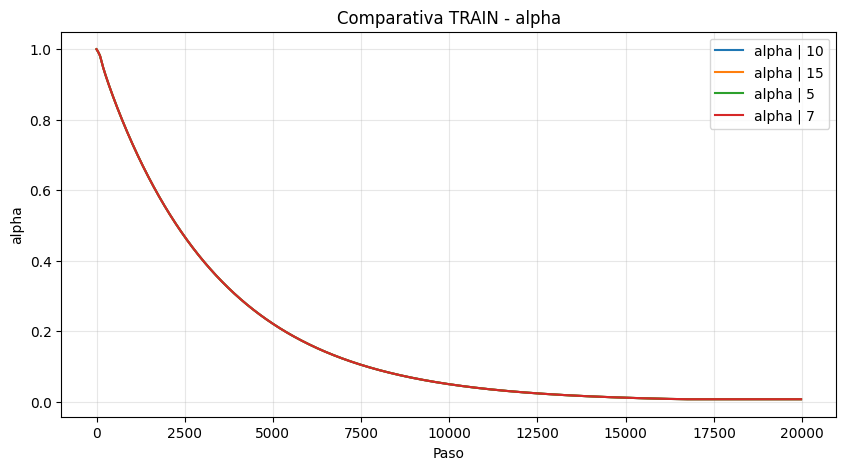

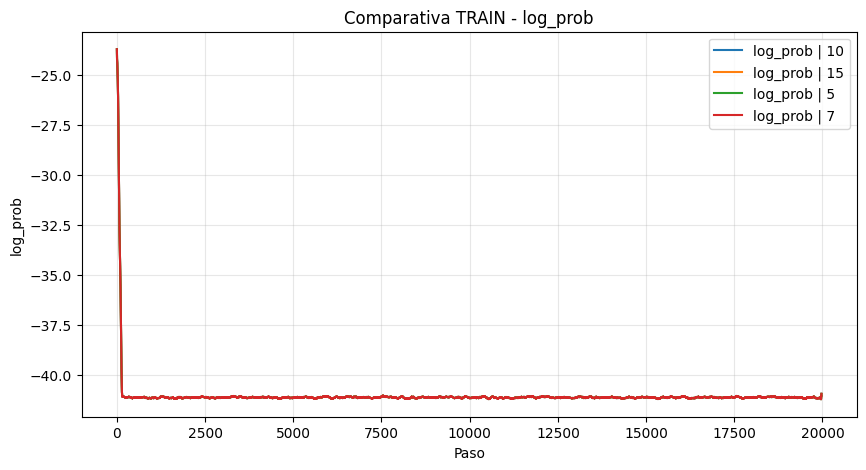

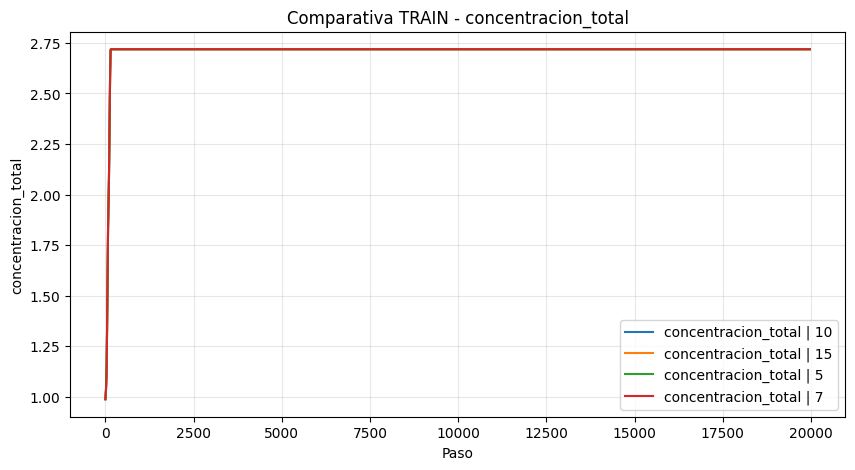

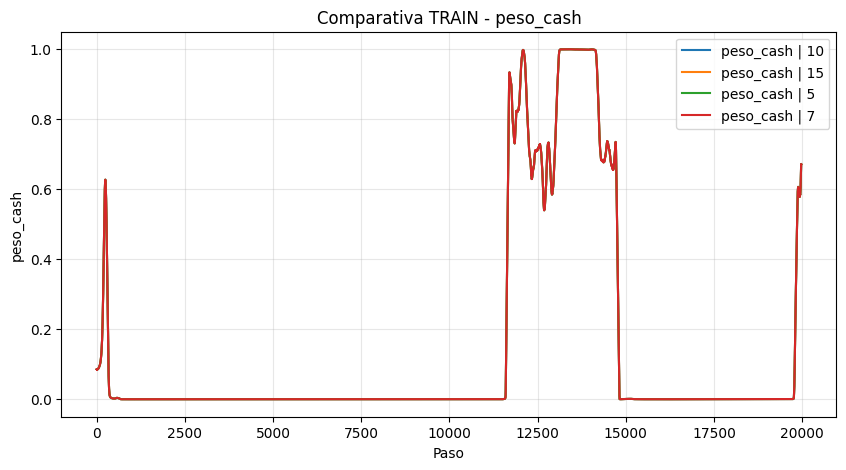

In [66]:
resumen_maxc = resumen_maxc.sort_values(by="sharpe", ascending=False)
mejor_max_concentration = resumen_maxc.iloc[0]["param_value"]
segundo_max_concentration = resumen_maxc.iloc[1]["param_value"]
plot_experiment_bundle(logs_maxc, smooth_window=100)

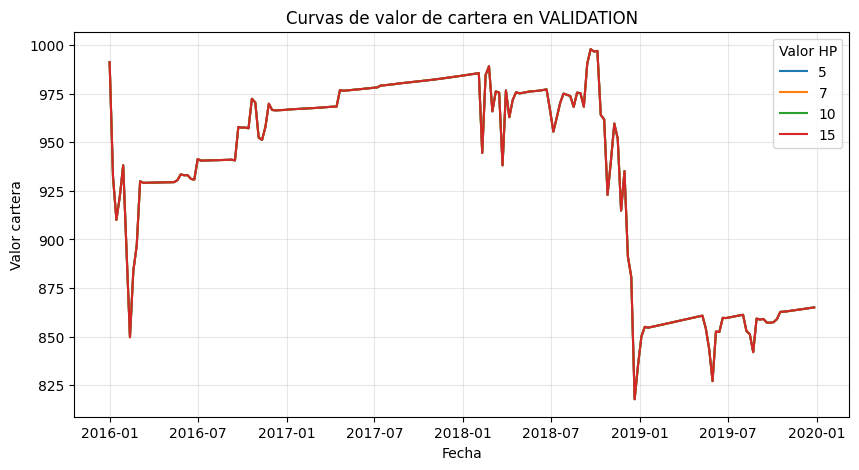

In [67]:
plot_validation_curves(curvas_maxc)

In [68]:
logs_target_entropy, resumen_target_entropy, curvas_target_entropy = run_experiments(
    param_name="offset_target_entropy",
    values=search_spaces["offset_target_entropy"],
    base_config=base_config,
    n_runs=1,
    seed_start=42,
)

Ejecutando: offset_target_entropy=0.0|run=0
[DIAGNÓSTICO INICIAL]
  mu: min=-2.0396  max=-0.0440  media=-1.8851
  std: min=0.9390  max=1.0489  media=0.9883
  log_prob: -18.8307  (target_entropy=-17.0000)
  residual inicial: -1.8307  (>0 → alpha sube, <0 → alpha baja)
  accion suma: 1.000000
  peso_cash inicial: 0.0937
[Paso     500] reward_media(200)=-0.002203 | critic1=7.001532 | critic2=7.121182 | actor=-95.447586 | alpha=0.881367 | Q_min=+58.028549 | Q1=+58.076370 | Q2=+58.095131 | target_Q=+58.627609 | gap_critics=0.114397 | log_prob=-41.485703 | log_prob_std=3.199799 | entropia=+41.485703 | mu_min=-59.7587 | mu_max=88.2369 | mu_media=-11.6729 | std_media=2.7183 | std_std=0.0000 | accion_min=1.070548e-13 | accion_max=0.999970 | peso_cash=0.003144 | residual=-24.123898 | riesgo=1.00
[CARTERA ACTUAL]
cash=1.000 | exposicion=0.000 | peso_max=0.000 | n_activos>1%=0 | top=sin activos
retorno=+0.000001 | pen_total=+0.002575 | reward=-0.003526 | dd=0.1244 | vol=0.014397 | cash=1.000 | rie

In [69]:
resumen_target_entropy.sort_values(by="sharpe", ascending=False)

,experiment_id,param_name,param_value,run_id,semilla,n_steps_train,tail_n_train,recompensas_train_final_mean,recompensas_train_final_std,perdida_actor_train_final_mean,...,log_prob_train_final_std,concentracion_total_train_final_mean,concentracion_total_train_final_std,peso_cash_train_final_mean,peso_cash_train_final_std,retorno_acumulado,retorno_anualizado,volatilidad_anualizada,sharpe,max_drawdown
4,offset_target_entropy=-7.0|run=0,offset_target_entropy,-7.0,0,42,20000,4000,-0.000690,0.009499,-185.615240,...,0.257687,2.718281,0.0,6.544990e-10,8.604177e-10,0.286919,0.065094,0.049757,1.035647,-0.058429
1,offset_target_entropy=-1.0|run=0,offset_target_entropy,-1.0,0,42,20000,4000,-0.000997,0.024533,-257.558707,...,0.257687,2.718281,0.0,2.911703e-05,4.553091e-05,0.527647,0.111747,0.111667,0.891168,-0.119686
0,offset_target_entropy=0.0|run=0,offset_target_entropy,0.0,0,42,20000,4000,-0.001367,0.025603,-213.201415,...,0.257687,2.718281,0.0,7.467282e-08,1.938052e-07,0.520049,0.110362,0.157555,0.662263,-0.280454
3,offset_target_entropy=-5.0|run=0,offset_target_entropy,-5.0,0,42,20000,4000,-0.001937,0.024011,-214.708802,...,0.257687,2.718281,0.0,1.581948e-02,9.444928e-02,-0.127359,-0.033484,0.098628,-0.425152,-0.180547
2,offset_target_entropy=-3.0|run=0,offset_target_entropy,-3.0,0,42,20000,4000,-0.002188,0.018339,-227.592938,...,0.257687,2.718281,0.0,2.349267e-01,2.311137e-01,-0.127623,-0.033558,0.076535,-0.574838,-0.191527


/var/folders/zs/dhnrx1c162j9vl24z5zd95tm0000gn/T/ipykernel_3371/118487996.py:11: RuntimeWarning: Mean of empty slice
  out[i] = np.nanmean(x[start:i+1])


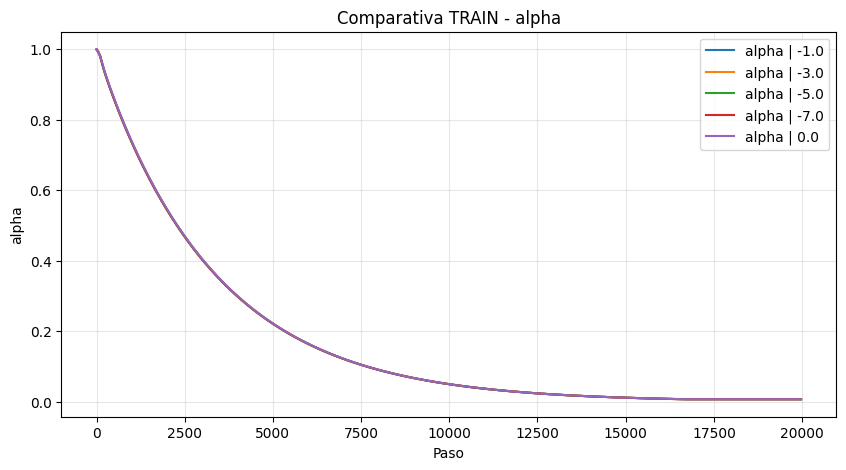

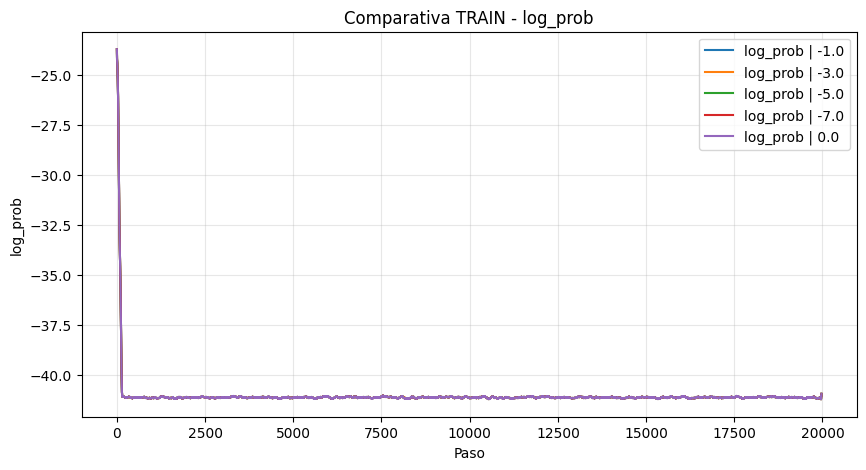

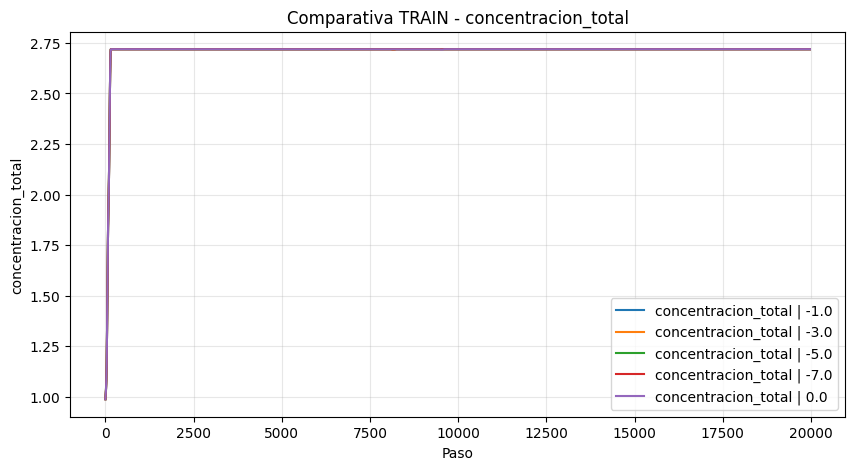

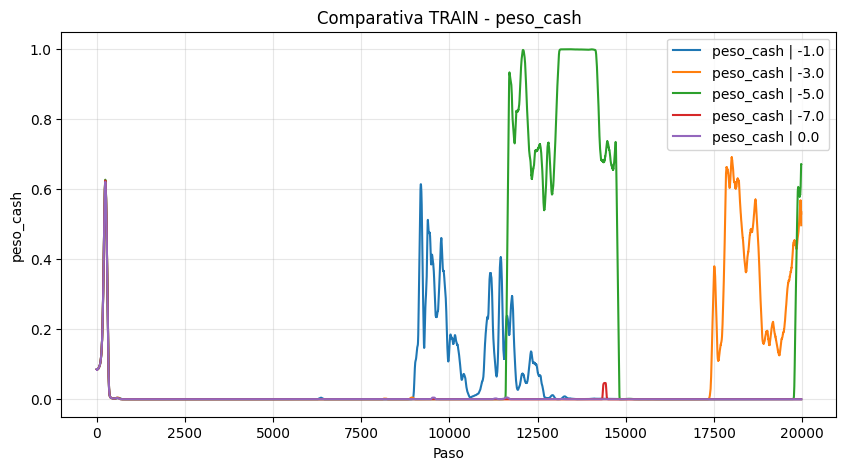

In [70]:
resumen_target_entropy = resumen_target_entropy.sort_values(by="sharpe", ascending=False)
mejor_offset_target_entropy = resumen_target_entropy.iloc[0]["param_value"]
segundo_offset_target_entropy = resumen_target_entropy.iloc[1]["param_value"]
plot_experiment_bundle(logs_target_entropy, smooth_window=100)

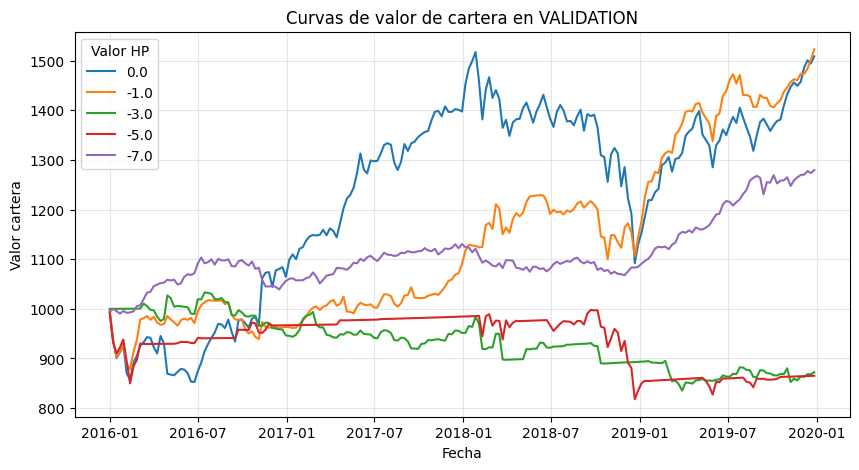

In [71]:
plot_validation_curves(curvas_target_entropy)

In [72]:
logs_gamma, resumen_gamma, curvas_gamma = run_experiments(
    param_name="gamma",
    values=search_spaces["gamma"],
    base_config=base_config,
    n_runs=1,
    seed_start=42,
)

Ejecutando: gamma=0.87|run=0
[DIAGNÓSTICO INICIAL]
  mu: min=-2.0396  max=-0.0440  media=-1.8851
  std: min=0.9390  max=1.0489  media=0.9883
  log_prob: -18.8307  (target_entropy=-22.0000)
  residual inicial: 3.1693  (>0 → alpha sube, <0 → alpha baja)
  accion suma: 1.000000
  peso_cash inicial: 0.0937
[Paso     500] reward_media(200)=-0.002203 | critic1=5.312821 | critic2=5.335343 | actor=-85.499916 | alpha=0.878289 | Q_min=+48.410492 | Q1=+48.525352 | Q2=+48.429512 | target_Q=+48.978680 | gap_critics=0.133882 | log_prob=-41.485703 | log_prob_std=3.199799 | entropia=+41.485703 | mu_min=-54.8887 | mu_max=78.6762 | mu_media=-9.0976 | std_media=2.7183 | std_std=0.0000 | accion_min=1.865735e-12 | accion_max=0.994209 | peso_cash=0.003874 | residual=-19.123898 | riesgo=1.00
[CARTERA ACTUAL]
cash=1.000 | exposicion=0.000 | peso_max=0.000 | n_activos>1%=0 | top=sin activos
retorno=+0.000001 | pen_total=+0.002575 | reward=-0.003526 | dd=0.1244 | vol=0.014397 | cash=1.000 | riesgo=1.00 || pen_d

KeyboardInterrupt: 

In [ ]:
resumen_gamma.sort_values(by="sharpe", ascending=False)

,experiment_id,param_name,param_value,run_id,semilla,n_steps_train,tail_n_train,recompensas_train_final_mean,recompensas_train_final_std,perdida_actor_train_final_mean,...,log_prob_train_final_std,concentracion_total_train_final_mean,concentracion_total_train_final_std,peso_cash_train_final_mean,peso_cash_train_final_std,retorno_acumulado,retorno_anualizado,volatilidad_anualizada,sharpe,max_drawdown
1,gamma=0.9|run=0,gamma,0.90,0,42,20000,4000,0.000344,0.010125,-1.995679,...,0.164948,19.999995,7.702481e-05,0.073201,0.012808,0.413682,0.090687,0.083578,0.926443,-0.147349
2,gamma=0.95|run=0,gamma,0.95,0,42,20000,4000,0.000167,0.008921,10.959106,...,0.167188,19.999997,5.866852e-05,0.068550,0.010622,0.362539,0.080656,0.079794,0.850719,-0.144476
0,gamma=0.87|run=0,gamma,0.87,0,42,20000,4000,0.000159,0.009242,-0.367415,...,0.164114,20.000000,7.354641e-07,0.070185,0.009196,0.299208,0.067836,0.076319,0.729505,-0.136080
3,gamma=0.99|run=0,gamma,0.99,0,42,20000,4000,0.000191,0.009667,145.548309,...,0.173826,20.000000,0.000000e+00,0.063589,0.008884,0.249687,0.057481,0.087394,0.535982,-0.188820


/var/folders/zs/dhnrx1c162j9vl24z5zd95tm0000gn/T/ipykernel_6900/118487996.py:11: RuntimeWarning: Mean of empty slice
  out[i] = np.nanmean(x[start:i+1])


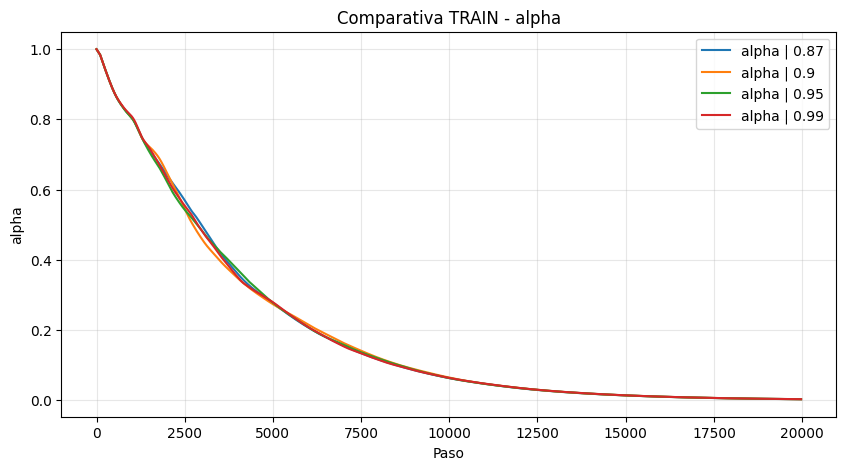

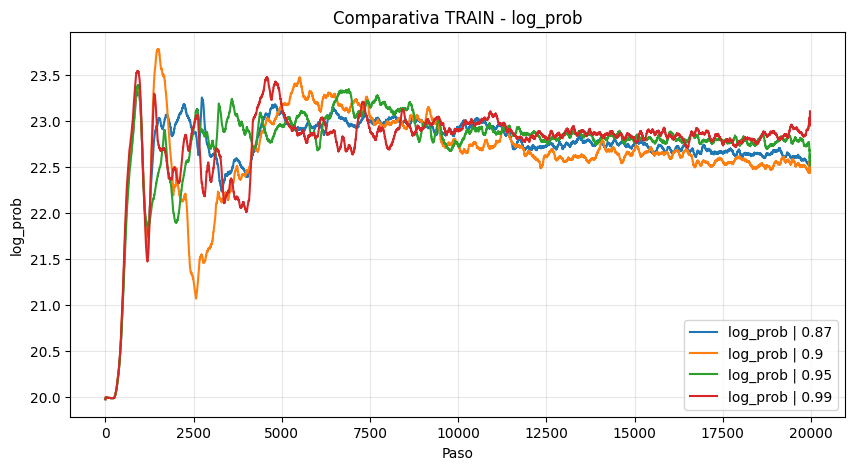

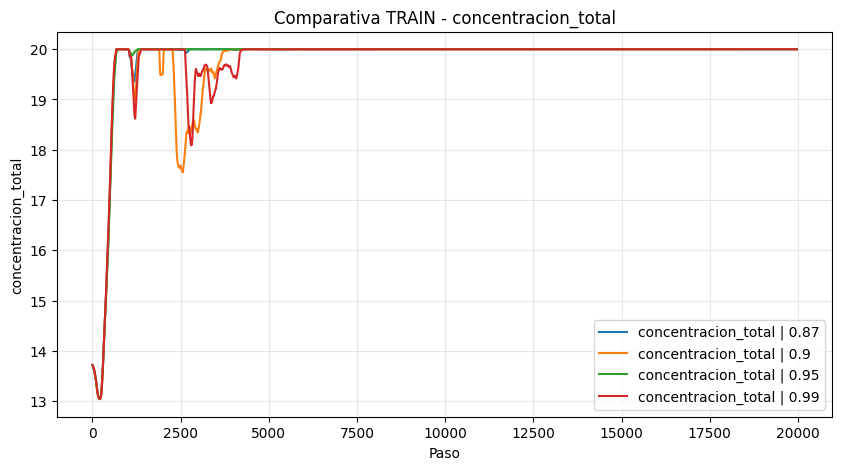

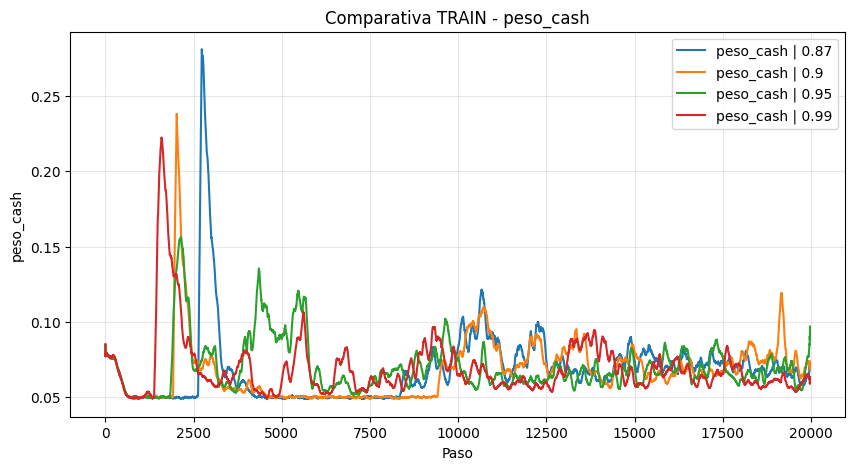

In [ ]:
resumen_gamma = resumen_gamma.sort_values(by="sharpe", ascending=False)
mejor_gamma = resumen_gamma.iloc[0]["param_value"]
segundo_gamma = resumen_gamma.iloc[1]["param_value"]
plot_experiment_bundle(logs_gamma, smooth_window=100)

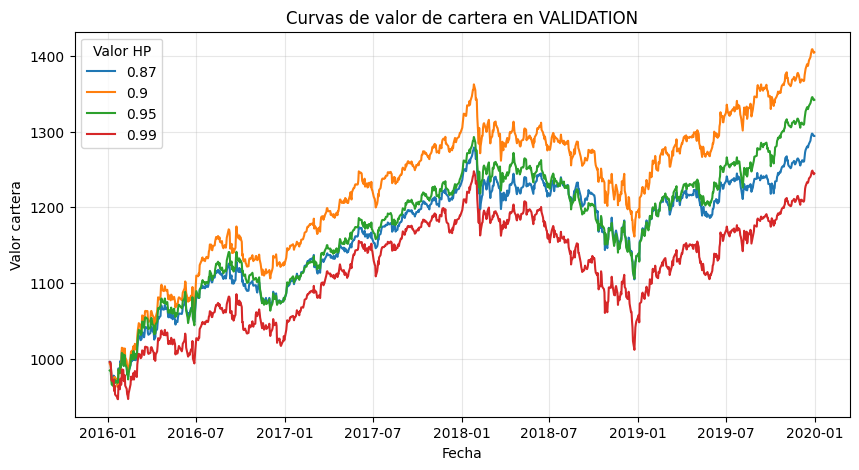

In [ ]:
plot_validation_curves(curvas_gamma)

In [ ]:
logs_tau, resumen_tau, curvas_tau = run_experiments(
    param_name="tau",
    values=search_spaces["tau"],
    base_config=base_config,
    n_runs=1,
    seed_start=42,
)

Ejecutando: tau=0.0001|run=0
[Paso     500] recompensa_media(200)=+0.000290 | perdida_critic1=364.656891 | perdida_critic2=362.730682 | perdida_actor=35.944233 | alpha=0.894841 | Q_min=-18.148109 | Q1=-18.037706 | Q2=-18.060360 | target_Q=-16.946562 | gap_critics=0.198152 | log_prob=+20.286631 | log_prob_std=0.652072 | entropia=-20.271164 | conc_min=1.000162 | conc_max=1.616349 | conc_media=1.148710 | conc_total=14.933237 | conc_total_std=0.029863 | accion_min=4.326395e-04 | accion_max=0.436166 | peso_cash=0.061102 | residual_entropia=-4.766502riesgo=1.00 | 
[Paso    1000] recompensa_media(200)=-0.000951 | perdida_critic1=514.148926 | perdida_critic2=512.919983 | perdida_actor=33.551918 | alpha=0.796230 | Q_min=-19.357830 | Q1=-19.261486 | Q2=-19.166458 | target_Q=-18.295914 | gap_critics=0.287714 | log_prob=+22.429287 | log_prob_std=1.765503 | entropia=-22.525925 | conc_min=1.000000 | conc_max=4.446481 | conc_media=1.538221 | conc_total=19.996866 | conc_total_std=0.022241 | accion_min

In [ ]:
resumen_tau.sort_values(by="sharpe", ascending=False)

,experiment_id,param_name,param_value,run_id,semilla,n_steps_train,tail_n_train,recompensas_train_final_mean,recompensas_train_final_std,perdida_actor_train_final_mean,...,log_prob_train_final_std,concentracion_total_train_final_mean,concentracion_total_train_final_std,peso_cash_train_final_mean,peso_cash_train_final_std,retorno_acumulado,retorno_anualizado,volatilidad_anualizada,sharpe,max_drawdown
2,tau=0.0005|run=0,tau,0.0005,0,42,20000,4000,0.000193,0.009166,23.862533,...,0.153100,19.999999,0.000050,0.096779,0.012444,0.348173,0.077788,0.086878,0.757523,-0.174881
0,tau=0.0001|run=0,tau,0.0001,0,42,20000,4000,0.000216,0.009436,8.385975,...,0.159257,19.999956,0.000436,0.085519,0.009554,0.321551,0.072411,0.080328,0.750227,-0.153329
1,tau=0.0003|run=0,tau,0.0003,0,42,20000,4000,0.000167,0.009064,17.069772,...,0.146749,19.999992,0.000117,0.058516,0.006709,0.301086,0.068223,0.081333,0.693862,-0.155723
3,tau=0.001|run=0,tau,0.0010,0,42,20000,4000,-0.000055,0.008532,45.982739,...,0.150132,19.999995,0.000088,0.083775,0.010580,0.252002,0.057972,0.076250,0.608420,-0.169760


/var/folders/zs/dhnrx1c162j9vl24z5zd95tm0000gn/T/ipykernel_6900/118487996.py:11: RuntimeWarning: Mean of empty slice
  out[i] = np.nanmean(x[start:i+1])


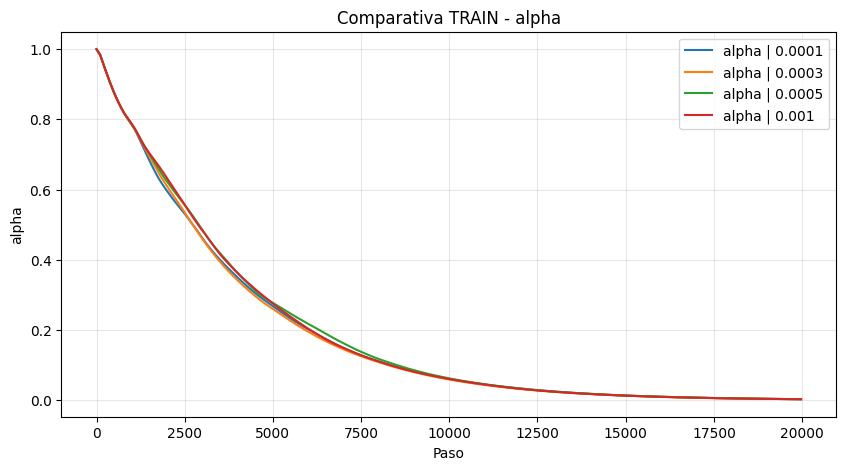

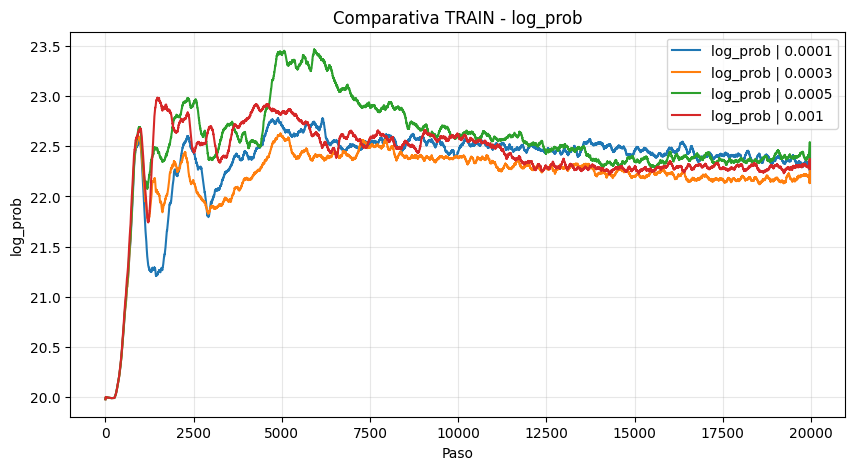

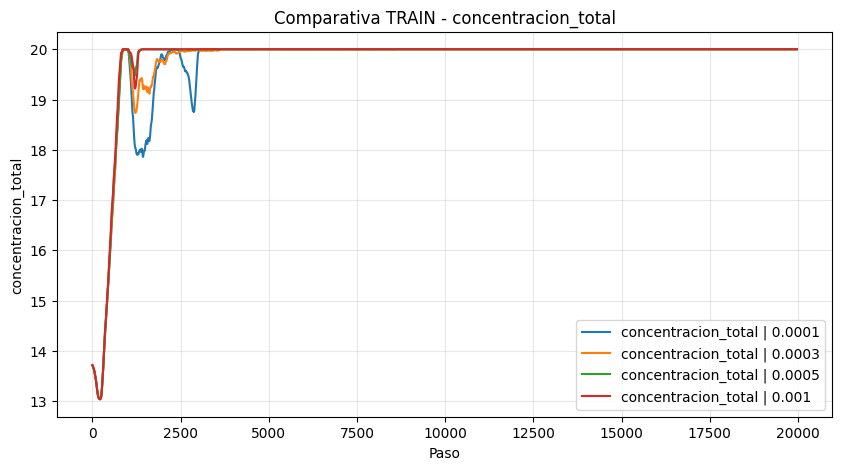

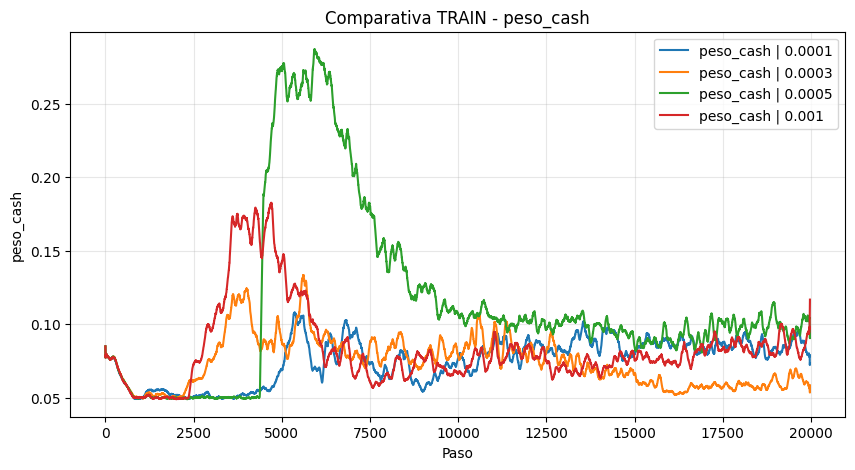

In [ ]:
resumen_tau = resumen_tau.sort_values(by="sharpe", ascending=False)
mejor_tau = resumen_tau.iloc[0]["param_value"]
segundo_tau = resumen_tau.iloc[1]["param_value"]
plot_experiment_bundle(logs_tau, smooth_window=100)

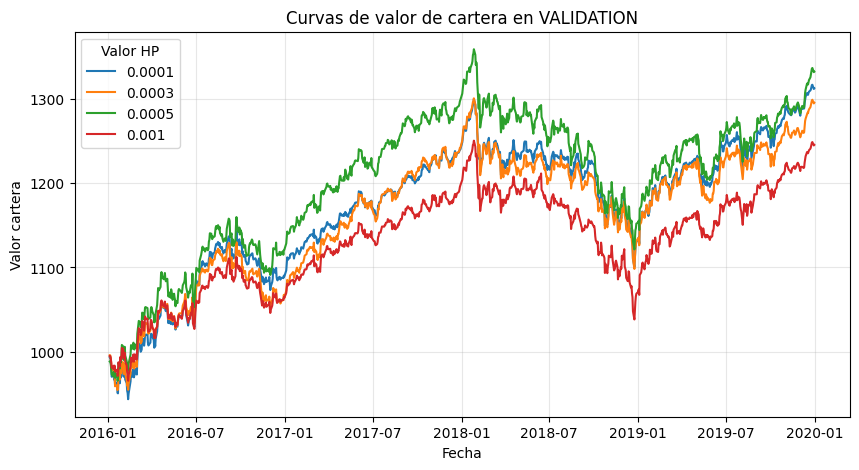

In [ ]:
plot_validation_curves(curvas_tau)

In [ ]:
logs_lr_actor, resumen_lr_actor, curvas_lr_actor = run_experiments(
    param_name="lr_actor",
    values=search_spaces["lr_actor"],
    base_config=base_config,
    n_runs=1,
    seed_start=42,
)

Ejecutando: lr_actor=5e-05|run=0
[Paso     500] recompensa_media(200)=+0.000290 | perdida_critic1=361.197327 | perdida_critic2=357.987885 | perdida_actor=48.543640 | alpha=0.894179 | Q_min=-30.560701 | Q1=-30.384665 | Q2=-30.412151 | target_Q=-29.481150 | gap_critics=0.324590 | log_prob=+20.083256 | log_prob_std=0.481618 | entropia=-20.130270 | conc_min=1.002858 | conc_max=1.533115 | conc_media=1.089882 | conc_total=14.168460 | conc_total_std=0.034413 | accion_min=1.028523e-04 | accion_max=0.428698 | peso_cash=0.068594 | residual_entropia=-4.898293riesgo=1.00 | 
[Paso    1000] recompensa_media(200)=-0.000951 | perdida_critic1=507.111420 | perdida_critic2=505.914917 | perdida_actor=74.932640 | alpha=0.814443 | Q_min=-61.561172 | Q1=-61.443611 | Q2=-61.369278 | target_Q=-61.397530 | gap_critics=0.309460 | log_prob=+23.552687 | log_prob_std=1.783048 | entropia=-23.487585 | conc_min=1.000000 | conc_max=7.161491 | conc_media=1.538462 | conc_total=20.000000 | conc_total_std=0.000000 | accion

In [ ]:
resumen_lr_actor.sort_values(by="sharpe", ascending=False)

,experiment_id,param_name,param_value,run_id,semilla,n_steps_train,tail_n_train,recompensas_train_final_mean,recompensas_train_final_std,perdida_actor_train_final_mean,...,log_prob_train_final_std,concentracion_total_train_final_mean,concentracion_total_train_final_std,peso_cash_train_final_mean,peso_cash_train_final_std,retorno_acumulado,retorno_anualizado,volatilidad_anualizada,sharpe,max_drawdown
1,lr_actor=0.0001|run=0,lr_actor,0.00010,0,42,20000,4000,0.000196,0.009258,147.880028,...,0.170324,20.000000,0.000014,0.091657,0.017042,0.287821,0.065481,0.076523,0.698959,-0.142873
0,lr_actor=5e-05|run=0,lr_actor,0.00005,0,42,20000,4000,-0.000006,0.008871,179.102251,...,0.172296,19.999996,0.000093,0.091707,0.015890,0.272993,0.062392,0.075490,0.669047,-0.158303
3,lr_actor=0.0005|run=0,lr_actor,0.00050,0,42,20000,4000,0.000154,0.009702,154.536232,...,0.167764,19.999997,0.000068,0.049983,0.004195,0.265655,0.060853,0.085495,0.583143,-0.183801
2,lr_actor=0.0003|run=0,lr_actor,0.00030,0,42,20000,4000,0.000191,0.009667,145.548309,...,0.173826,20.000000,0.000000,0.063589,0.008884,0.249687,0.057481,0.087394,0.535982,-0.188820


/var/folders/zs/dhnrx1c162j9vl24z5zd95tm0000gn/T/ipykernel_6900/118487996.py:11: RuntimeWarning: Mean of empty slice
  out[i] = np.nanmean(x[start:i+1])


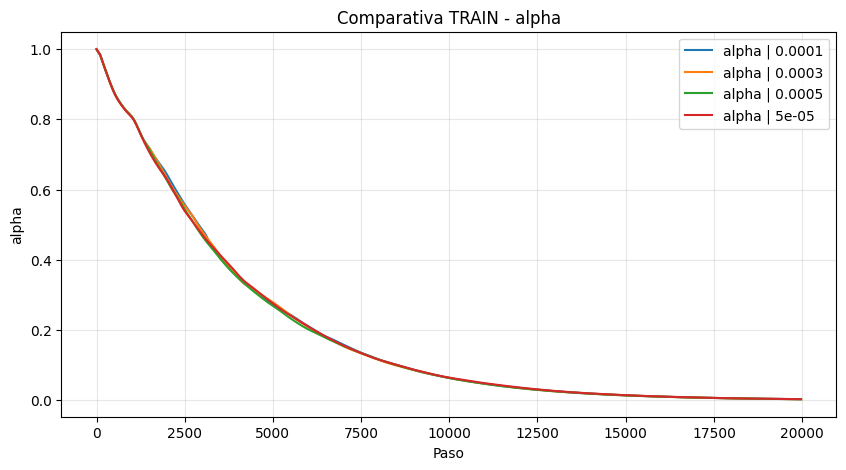

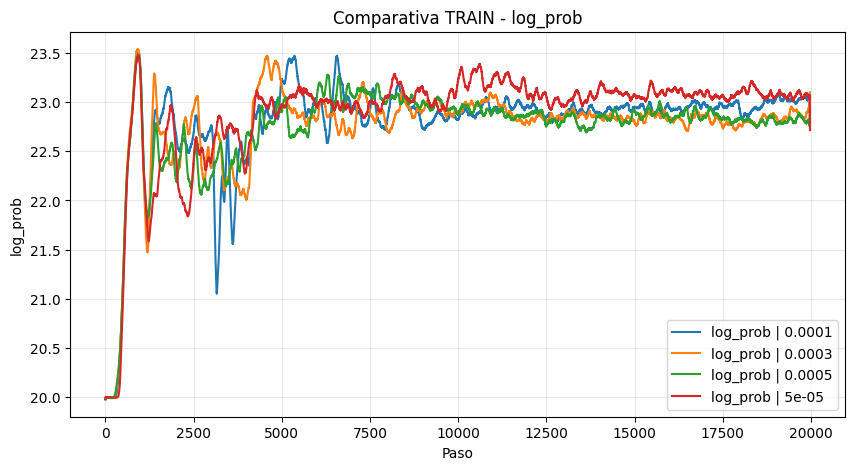

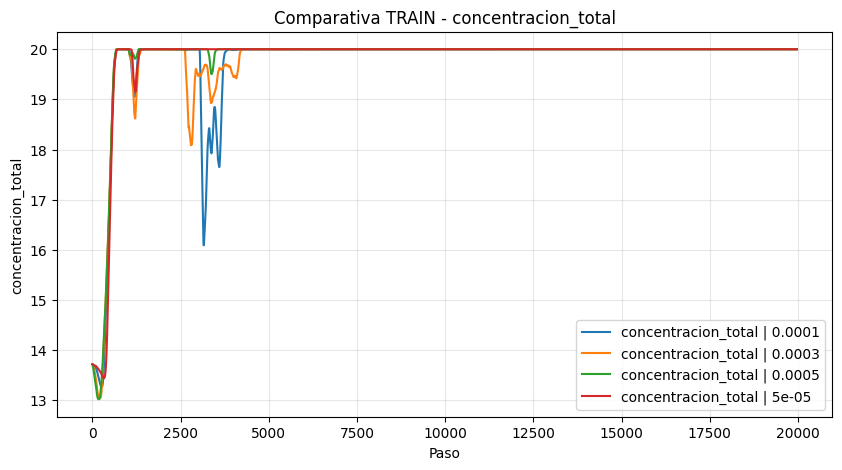

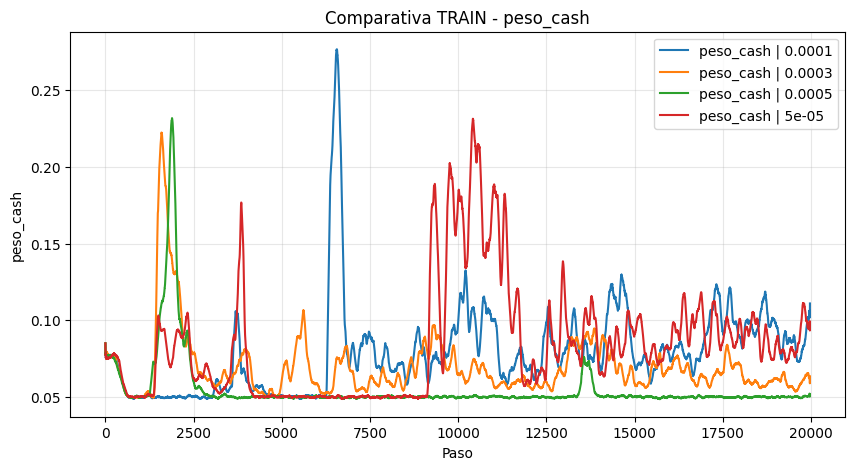

In [ ]:
resumen_lr_actor = resumen_lr_actor.sort_values(by="sharpe", ascending=False)
mejor_lr_actor = resumen_lr_actor.iloc[0]["param_value"]
segundo_lr_actor = resumen_lr_actor.iloc[1]["param_value"]
plot_experiment_bundle(logs_lr_actor, smooth_window=100)

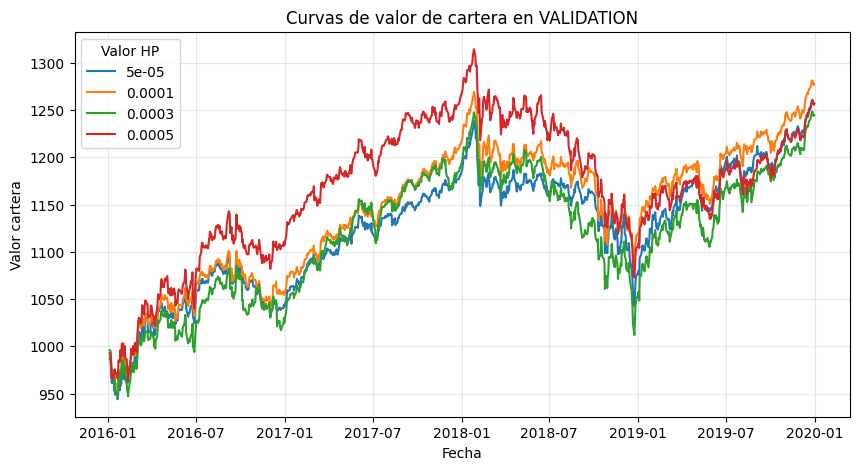

In [ ]:
plot_validation_curves(curvas_lr_actor)

In [ ]:
logs_lr_criticos, resumen_lr_criticos, curvas_lr_criticos = run_experiments(
    param_name="lr_criticos",
    values=search_spaces["lr_criticos"],
    base_config=base_config,
    n_runs=1,
    seed_start=42,
)

Ejecutando: lr_criticos=0.0001|run=0
[Paso     500] recompensa_media(200)=+0.000290 | perdida_critic1=436.358795 | perdida_critic2=406.876984 | perdida_actor=33.287415 | alpha=0.894085 | Q_min=-15.315186 | Q1=-13.043717 | Q2=-15.315186 | target_Q=-20.435091 | gap_critics=2.271468 | log_prob=+19.987022 | log_prob_std=0.005571 | entropia=-19.987228 | conc_min=1.000543 | conc_max=1.004321 | conc_media=1.001521 | conc_total=13.019774 | conc_total_std=0.002745 | accion_min=9.945343e-05 | accion_max=0.527855 | peso_cash=0.077692 | residual_entropia=-4.999811riesgo=1.00 | 
[Paso    1000] recompensa_media(200)=-0.000951 | perdida_critic1=494.735535 | perdida_critic2=495.066254 | perdida_actor=62.931114 | alpha=0.770641 | Q_min=-47.599766 | Q1=-47.355633 | Q2=-47.460724 | target_Q=-47.978340 | gap_critics=0.383178 | log_prob=+20.274271 | log_prob_std=0.563470 | entropia=-20.215302 | conc_min=1.000023 | conc_max=1.566469 | conc_media=1.114328 | conc_total=14.486258 | conc_total_std=0.041476 | ac

In [ ]:
resumen_lr_criticos.sort_values(by="sharpe", ascending=False)

,experiment_id,param_name,param_value,run_id,semilla,n_steps_train,tail_n_train,recompensas_train_final_mean,recompensas_train_final_std,perdida_actor_train_final_mean,...,log_prob_train_final_std,concentracion_total_train_final_mean,concentracion_total_train_final_std,peso_cash_train_final_mean,peso_cash_train_final_std,retorno_acumulado,retorno_anualizado,volatilidad_anualizada,sharpe,max_drawdown
0,lr_criticos=0.0001|run=0,lr_criticos,0.0001,0,42,20000,4000,-1.457079e-05,0.010088,161.291577,...,0.194738,20.000000,0.000000,0.111463,0.021931,0.294486,0.066861,0.078152,0.702578,-0.154540
2,lr_criticos=0.0007|run=0,lr_criticos,0.0007,0,42,20000,4000,2.217822e-04,0.009227,156.250012,...,0.155384,19.999978,0.000272,0.074089,0.010975,0.297399,0.067463,0.083086,0.672384,-0.181279
1,lr_criticos=0.0005|run=0,lr_criticos,0.0005,0,42,20000,4000,-5.043399e-07,0.008584,171.159733,...,0.165677,19.999995,0.000120,0.090800,0.012852,0.171026,0.040382,0.075322,0.392438,-0.167599


/var/folders/zs/dhnrx1c162j9vl24z5zd95tm0000gn/T/ipykernel_6900/118487996.py:11: RuntimeWarning: Mean of empty slice
  out[i] = np.nanmean(x[start:i+1])


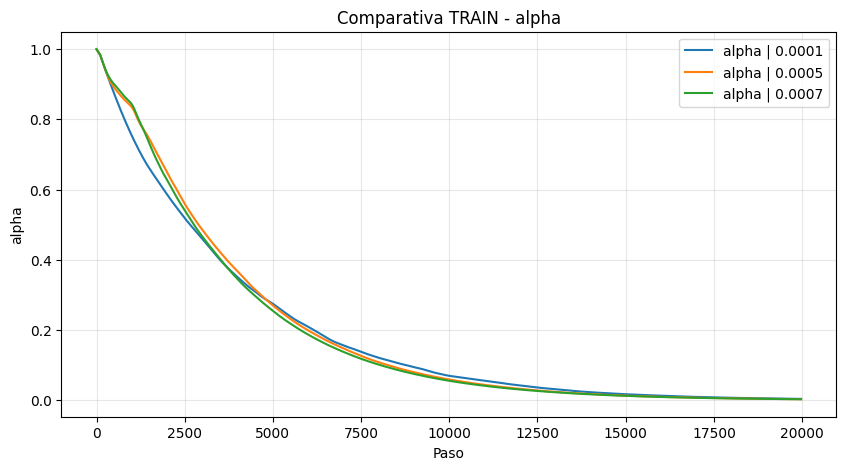

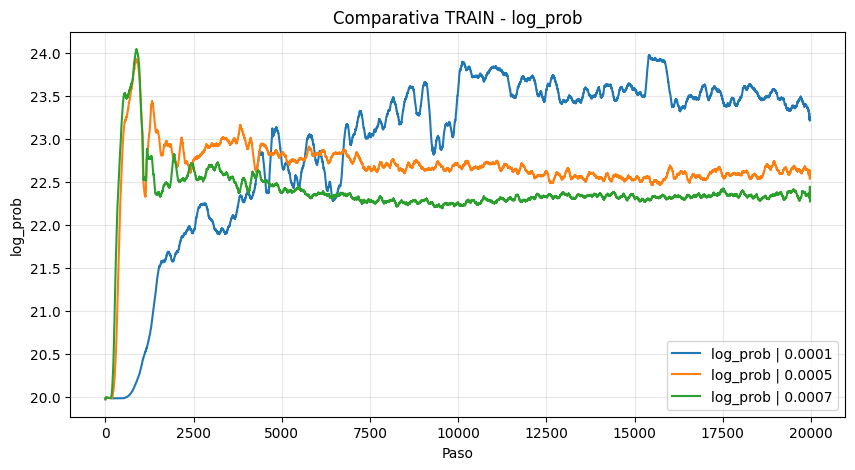

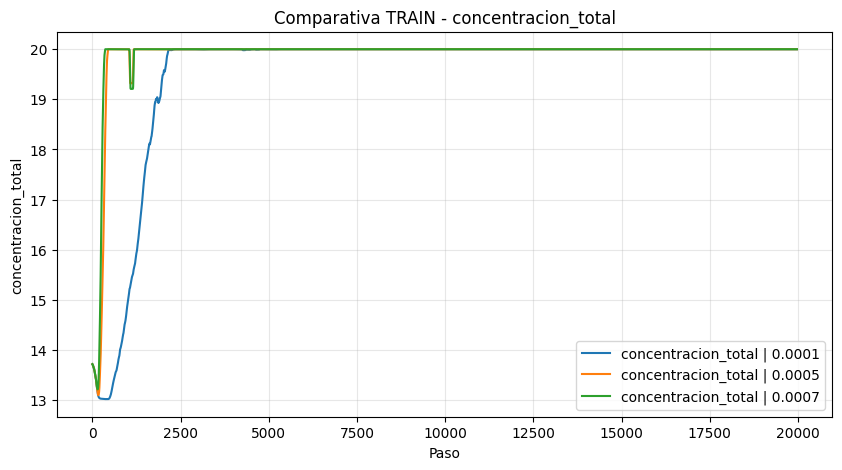

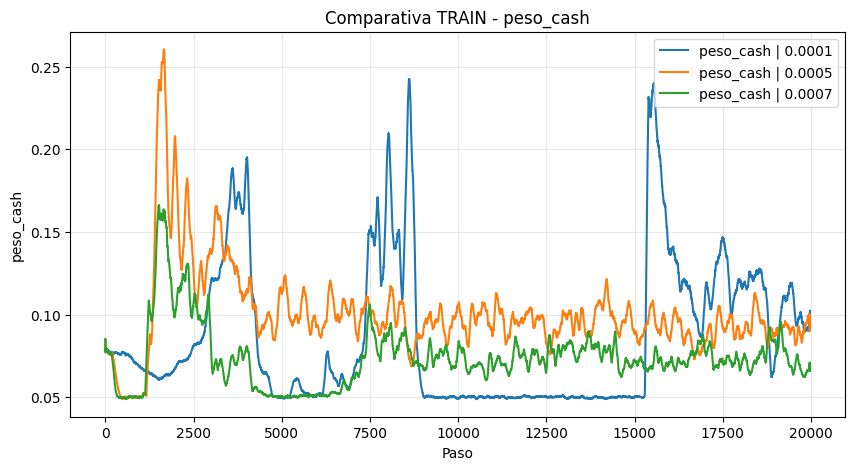

In [ ]:
resumen_lr_criticos = resumen_lr_criticos.sort_values(by="sharpe", ascending=False)
mejor_lr_critic = resumen_lr_criticos.iloc[0]["param_value"]
segundo_lr_critic = resumen_lr_criticos.iloc[1]["param_value"]
plot_experiment_bundle(logs_lr_criticos, smooth_window=100)

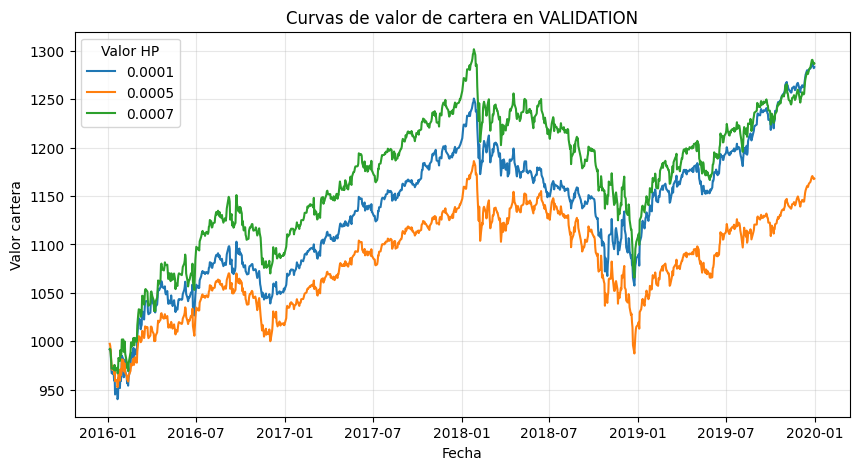

In [ ]:
plot_validation_curves(curvas_lr_criticos)

In [ ]:
logs_lr_alpha, resumen_lr_alpha, curvas_lr_alpha = run_experiments(
    param_name="lr_alpha",
    values=search_spaces["lr_alpha"],
    base_config=base_config,
    n_runs=1,
    seed_start=42,
)

Ejecutando: lr_alpha=0.0005|run=0
[Paso     500] recompensa_media(200)=+0.000290 | perdida_critic1=357.665558 | perdida_critic2=354.910248 | perdida_actor=45.536781 | alpha=0.831888 | Q_min=-29.054552 | Q1=-28.885172 | Q2=-28.926750 | target_Q=-28.083601 | gap_critics=0.297182 | log_prob=+20.726795 | log_prob_std=0.910866 | entropia=-20.571960 | conc_min=1.000036 | conc_max=1.983428 | conc_media=1.225021 | conc_total=15.925282 | conc_total_std=0.058029 | accion_min=1.209897e-04 | accion_max=0.418973 | peso_cash=0.053168 | residual_entropia=-4.430100riesgo=1.00 | 
[Paso    1000] recompensa_media(200)=-0.000951 | perdida_critic1=501.724243 | perdida_critic2=500.810516 | perdida_actor=66.636223 | alpha=0.716730 | Q_min=-55.620930 | Q1=-55.488949 | Q2=-55.462395 | target_Q=-55.523296 | gap_critics=0.290522 | log_prob=+23.273308 | log_prob_std=1.920948 | entropia=-23.602486 | conc_min=1.000000 | conc_max=7.272005 | conc_media=1.538462 | conc_total=20.000000 | conc_total_std=0.000000 | accio

In [ ]:
resumen_lr_alpha.sort_values(by="sharpe", ascending=False)

,experiment_id,param_name,param_value,run_id,semilla,n_steps_train,tail_n_train,recompensas_train_final_mean,recompensas_train_final_std,perdida_actor_train_final_mean,...,log_prob_train_final_std,concentracion_total_train_final_mean,concentracion_total_train_final_std,peso_cash_train_final_mean,peso_cash_train_final_std,retorno_acumulado,retorno_anualizado,volatilidad_anualizada,sharpe,max_drawdown
0,lr_alpha=0.0005|run=0,lr_alpha,0.0005,0,42,20000,4000,0.000199,0.009386,70.061503,...,0.176155,19.999994,0.000106,0.070335,0.013113,0.448317,0.097327,0.081665,1.020670,-0.095349
2,lr_alpha=0.002|run=0,lr_alpha,0.0020,0,42,20000,4000,0.000124,0.008602,-9.379879,...,0.169456,19.999999,0.000040,0.069743,0.008792,0.278874,0.063620,0.080906,0.643856,-0.149475
1,lr_alpha=0.001|run=0,lr_alpha,0.0010,0,42,20000,4000,0.000133,0.008327,23.339720,...,0.166815,19.999997,0.000057,0.090619,0.015686,0.243062,0.056073,0.070053,0.630137,-0.132723


/var/folders/zs/dhnrx1c162j9vl24z5zd95tm0000gn/T/ipykernel_6900/118487996.py:11: RuntimeWarning: Mean of empty slice
  out[i] = np.nanmean(x[start:i+1])


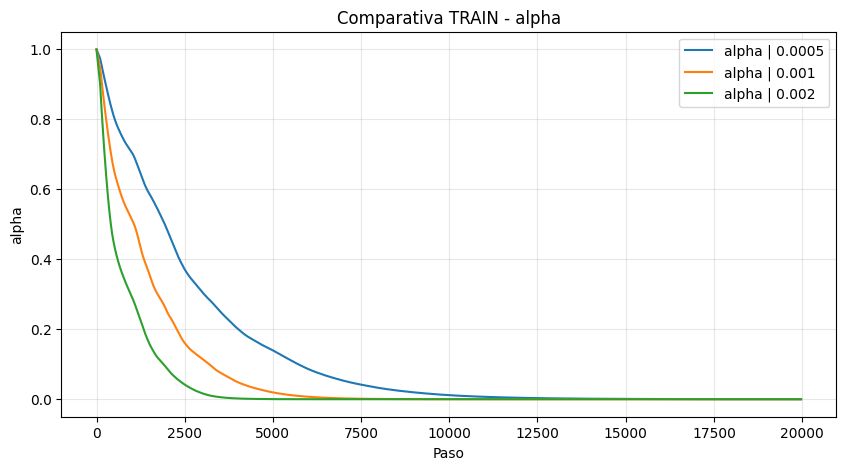

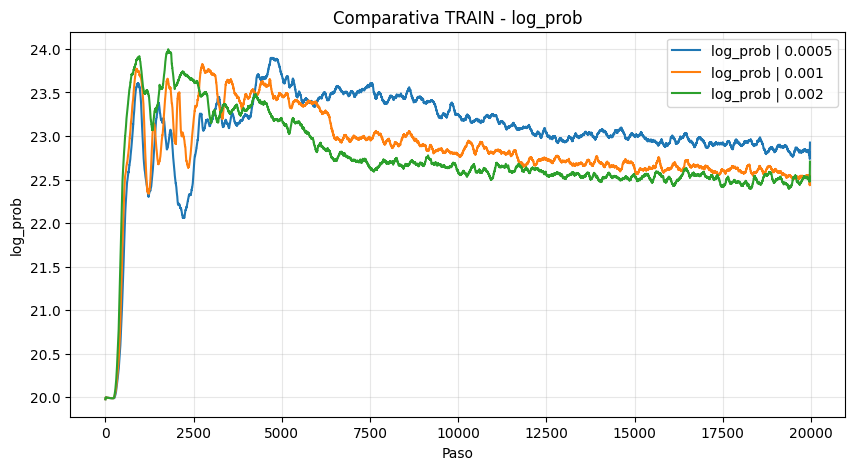

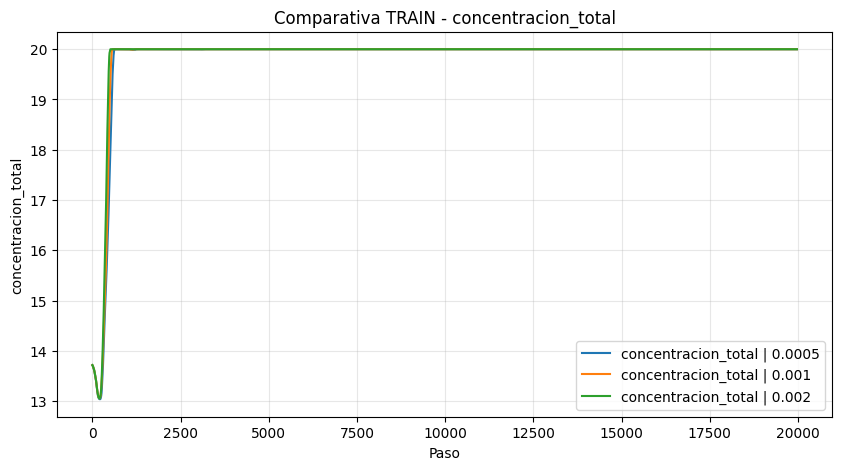

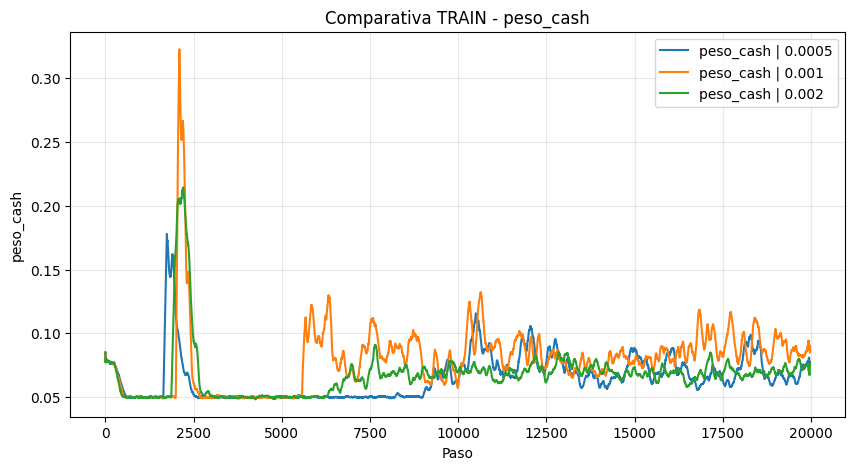

In [ ]:
resumen_lr_alpha = resumen_lr_alpha.sort_values(by="sharpe", ascending=False)
mejor_lr_alpha = resumen_lr_alpha.iloc[0]["param_value"]
segundo_lr_alpha = resumen_lr_alpha.iloc[1]["param_value"]
plot_experiment_bundle(logs_lr_alpha, smooth_window=100)

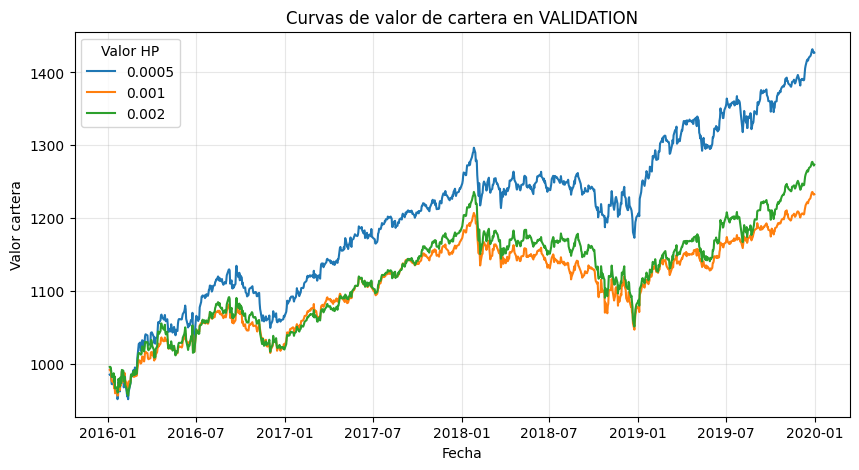

In [ ]:
plot_validation_curves(curvas_lr_alpha)

In [ ]:
logs_tamano_batch, resumen_tamano_batch, curvas_tamano_batch = run_experiments(
    param_name="tamano_batch",
    values=search_spaces["tamano_batch"],
    base_config=base_config,
    n_runs=1,
    seed_start=42,
)

Ejecutando: tamano_batch=64|run=0
[Paso     500] recompensa_media(200)=+0.000364 | perdida_critic1=270.835999 | perdida_critic2=270.867737 | perdida_actor=51.192005 | alpha=0.877492 | Q_min=-33.645920 | Q1=-33.427364 | Q2=-33.457245 | target_Q=-34.592453 | gap_critics=0.407227 | log_prob=+20.232292 | log_prob_std=0.498903 | entropia=-20.135559 | conc_min=1.000398 | conc_max=1.326998 | conc_media=1.127639 | conc_total=14.659307 | conc_total_std=0.034214 | accion_min=5.645740e-05 | accion_max=0.355543 | peso_cash=0.057911 | residual_entropia=-4.937712riesgo=1.00 | 
[Paso    1000] recompensa_media(200)=-0.000251 | perdida_critic1=356.180359 | perdida_critic2=354.857056 | perdida_actor=75.353180 | alpha=0.762168 | Q_min=-60.249760 | Q1=-60.019878 | Q2=-60.164375 | target_Q=-62.091286 | gap_critics=0.315263 | log_prob=+21.370968 | log_prob_std=0.921109 | entropia=-21.134506 | conc_min=1.000001 | conc_max=3.374460 | conc_media=1.342836 | conc_total=17.456871 | conc_total_std=0.090229 | accio

In [ ]:
resumen_tamano_batch.sort_values(by="sharpe", ascending=False)

,experiment_id,param_name,param_value,run_id,semilla,n_steps_train,tail_n_train,recompensas_train_final_mean,recompensas_train_final_std,perdida_actor_train_final_mean,...,log_prob_train_final_std,concentracion_total_train_final_mean,concentracion_total_train_final_std,peso_cash_train_final_mean,peso_cash_train_final_std,retorno_acumulado,retorno_anualizado,volatilidad_anualizada,sharpe,max_drawdown
0,tamano_batch=64|run=0,tamano_batch,64,0,42,20000,4000,0.000092,0.010327,150.849152,...,0.241832,19.999971,0.000461,0.096262,0.027860,0.469176,0.101268,0.090748,0.966647,-0.147445
2,tamano_batch=256|run=0,tamano_batch,256,0,42,20000,4000,0.000166,0.008914,160.645518,...,0.126771,19.999997,0.000074,0.114584,0.016954,0.261489,0.059976,0.072909,0.658803,-0.144866
1,tamano_batch=128|run=0,tamano_batch,128,0,42,20000,4000,0.000191,0.009667,145.548309,...,0.173826,20.000000,0.000000,0.063589,0.008884,0.249687,0.057481,0.087394,0.535982,-0.188820


/var/folders/zs/dhnrx1c162j9vl24z5zd95tm0000gn/T/ipykernel_6900/118487996.py:11: RuntimeWarning: Mean of empty slice
  out[i] = np.nanmean(x[start:i+1])


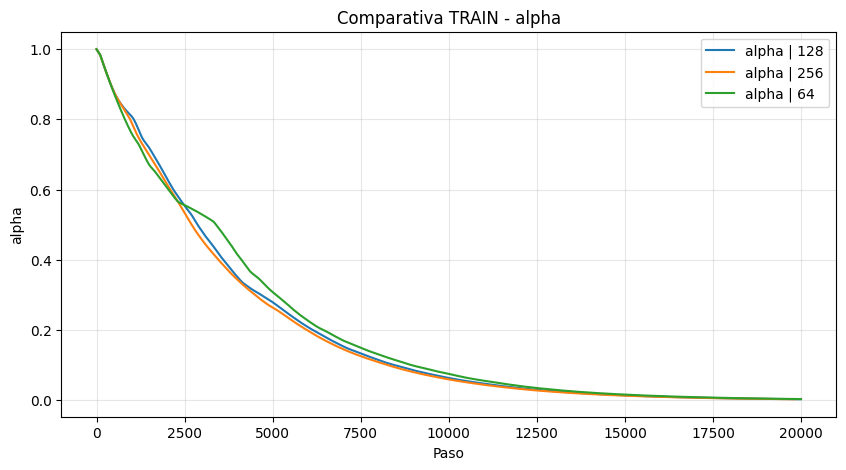

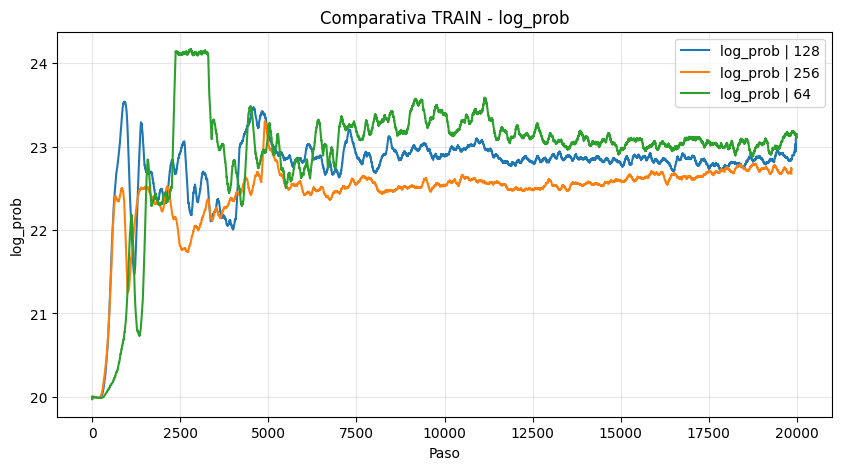

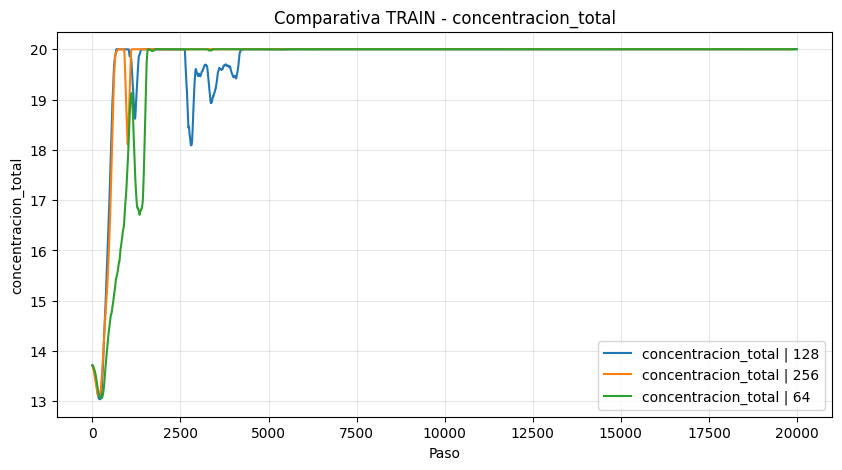

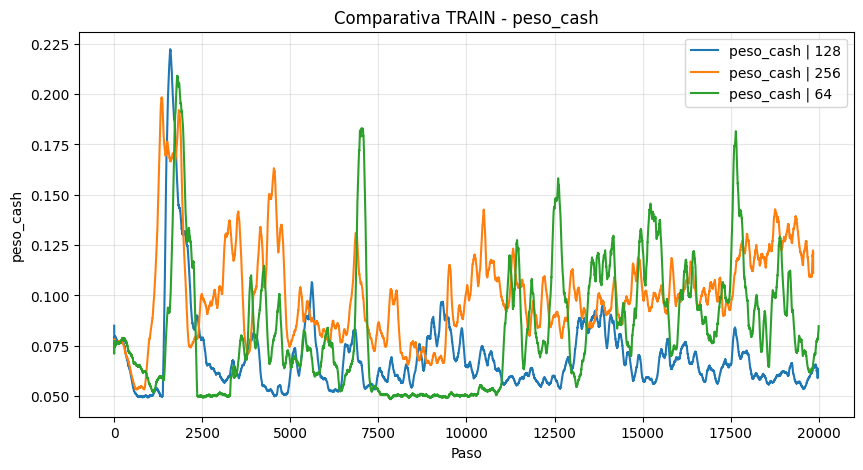

In [ ]:
resumen_tamano_batch = resumen_tamano_batch.sort_values(by="sharpe", ascending=False)
mejor_tamano_batch = resumen_tamano_batch.iloc[0]["param_value"]
segundo_tamano_batch = resumen_tamano_batch.iloc[1]["param_value"]
plot_experiment_bundle(logs_tamano_batch, smooth_window=100)

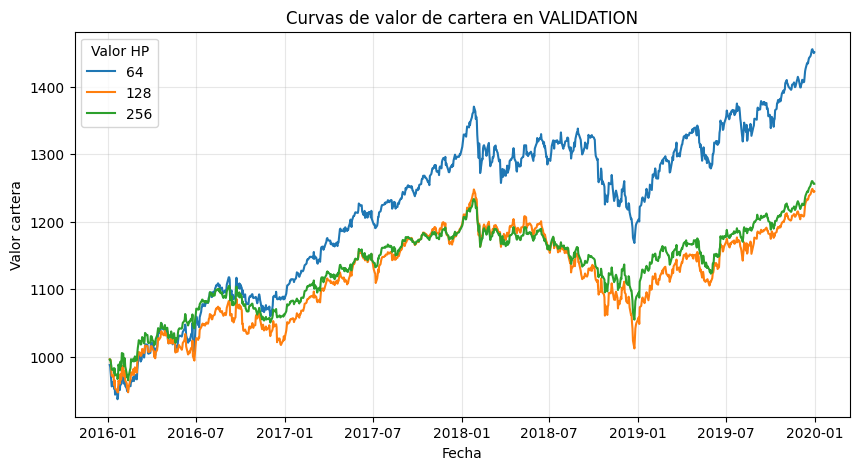

In [ ]:
plot_validation_curves(curvas_tamano_batch)

In [ ]:
print("Mejores valores para el máximo de concentración: ", mejor_max_concentration, "y", segundo_max_concentration,
      "\nMejores valores offset de entropía: ", mejor_offset_target_entropy, "y", segundo_offset_target_entropy,
      "\nMejores valores para gamma: ", mejor_gamma, "y", segundo_gamma,
      "\nMejores valores para tau: ", mejor_tau, "y", segundo_tau,
      "\nMejores valores para la tasa de aprendizaje del actor: ", mejor_lr_actor, "y", segundo_lr_actor,
      "\nMejores valores para la tasa de aprendizaje de los críticos: ", mejor_lr_critic, "y", segundo_lr_critic,
      "\nMejores valores para la tasa de aprendizaje de alpha: ", mejor_lr_alpha, "y", segundo_lr_alpha,
      "\nMejores valores para el tamaño del batch: ", mejor_tamano_batch, "y", segundo_tamano_batch,
)

Mejores valores para el máximo de concentración:  5 y 7 
Mejores valores offset de entropía:  0.0 y -1.0 
Mejores valores para gamma:  0.9 y 0.95 
Mejores valores para tau:  0.0005 y 0.0001 
Mejores valores para la tasa de aprendizaje del actor:  0.0001 y 5e-05 
Mejores valores para la tasa de aprendizaje de los críticos:  0.0001 y 0.0007 
Mejores valores para la tasa de aprendizaje de alpha:  0.0005 y 0.002 
Mejores valores para el tamaño del batch:  64 y 256
